# Test Accuracy Tables & Lyapunov Convergence Graphs

In [1]:
import os
os.environ.update(OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

In [2]:
%load_ext autoreload
import sys, time, json, copy
import functools, warnings
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
from joblib import Parallel, delayed

In [3]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [4]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed, save_to_pkl, load_from_pkl
from lib.classifier import ByzClassifier, load_run, save_run
from lib.system import SystemSimulator
from lib.metrics import MetricsCalculator
from lib.config import BASE_CONF, NUM_NODES
from lib.simulation import clf_stage, sim_task

**Experiment Configuration**

In [5]:
RUN_DIR = os.path.join(Path().resolve(), "baseline")
IMAGES_DIR = os.path.join(RUN_DIR, "images")
config = copy.deepcopy(BASE_CONF)

# Communication Graph
b = 5
config['graph_weights'] = 'MH_gen'
config['graph_args'] = {
    'ba_m': 5,
    'ws_k': 6,
    'ws_p': 0.1,
    'rand_reg_deg':10,
    'geom_radius':0.6,
    # 'geom_radius':0.4,
    'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
}

# Target stable Distribution
config['pi'] = (np.full(NUM_NODES, 1.0/NUM_NODES))
# config['pi-dir-alpha'] = 10
# pi = rng('dir','graphs').dirichlet(np.full(NUM_NODES,config['pi-dir-alpha']))
# config['pi'] = (pi / pi.sum())

# Classifier Training 
config['train']['b'] = b
config['train']['fpr_mean'] = 0.2
config['train']['fpr_spread'] = 0.05
config['train']['gamma_C'] = np.clip((config['train']['fpr_spread']*np.linspace(-1,1,NUM_NODES)) + \
                                     config['train']['fpr_mean'], 0, 0.95)

# System Simulation 
config['sys']['b'] = b
config['sys']['fpr_spread'] = 0.003

# Miscellaneous
config['train']['clf_model'] = 'xgb'
config['data_heterogeneity'] = 100
config['reg_param'] = 1

# Notebook Variables
graphs = ['random-regular','watts-strogatz', 'geometric', 'erdos-renyi', 'barabasi-albert']
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'ORACLE', 'IOS', 'SCC', 'TriMean', 'CooMed']
ALGS_TEST = ['RDSGD', 'ORACLE']
COLORS = dict(zip(ALGS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']))
SEEDS = [111,333,777,888,222]
DEBUG = True

In [6]:
# Save experiment configuration
payload = copy.deepcopy(config)
del payload['train']['gamma_C']
del payload['pi']
with open(os.path.join(RUN_DIR, f'config.json'), 'w') as f:
    def convert(o):
        if isinstance(o, np.generic):
            return o.item()
        raise TypeError(f'{type(o)} not serializable')
    json.dump(payload, f, indent=2, default=convert)

In [7]:
CACHE = {}
for g in graphs:
    cfg = copy.deepcopy(config)
    cfg['graph_type'] = g
    os.makedirs(os.path.join(RUN_DIR, g), exist_ok=True)
    CACHE[g] = cfg

In [8]:
# Train Byzantine classifier in parallel over 5 topologies
res1 = Parallel(n_jobs=5, backend='loky', inner_max_num_threads=6, verbose=10)(
    delayed(clf_stage)(g, CACHE[g], RUN_DIR, b) for g in graphs)
P1 = dict(res1)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  6.2min remaining:  9.2min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  7.0min remaining:  4.7min
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  9.3min finished


In [9]:
jobs = [(g, atk, s) for g in graphs for atk in ATKS for s in SEEDS]
res2 = Parallel(n_jobs=30, backend='loky', inner_max_num_threads=1, verbose=10)(
    delayed(sim_task)(g, CACHE[g], atk, s, P1[g]['proj_const'],
                      P1[g]['preproc'], P1[g]['est'], P1[g]['gamma_sys'],
                      dict(C_fpr=P1[g]['clf_thr']['fpr_ach'],
                           C_fnr=P1[g]['clf_thr']['fnr_ach'],
                           C_tau=P1[g]['clf_thr']['C_tau']),
                      ALGS, b, SEEDS)
    for g, atk, s in jobs)

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=30)]: Done   1 tasks      | elapsed:  5.5min
[Parallel(n_jobs=30)]: Done  12 tasks      | elapsed:  6.4min
[Parallel(n_jobs=30)]: Done  25 tasks      | elapsed:  6.4min
[Parallel(n_jobs=30)]: Done  38 tasks      | elapsed: 11.9min
[Parallel(n_jobs=30)]: Done  53 tasks      | elapsed: 13.0min
[Parallel(n_jobs=30)]: Done  79 out of 125 | elapsed: 18.8min remaining: 10.9min
[Parallel(n_jobs=30)]: Done 125 out of 125 | elapsed: 26.1min finished


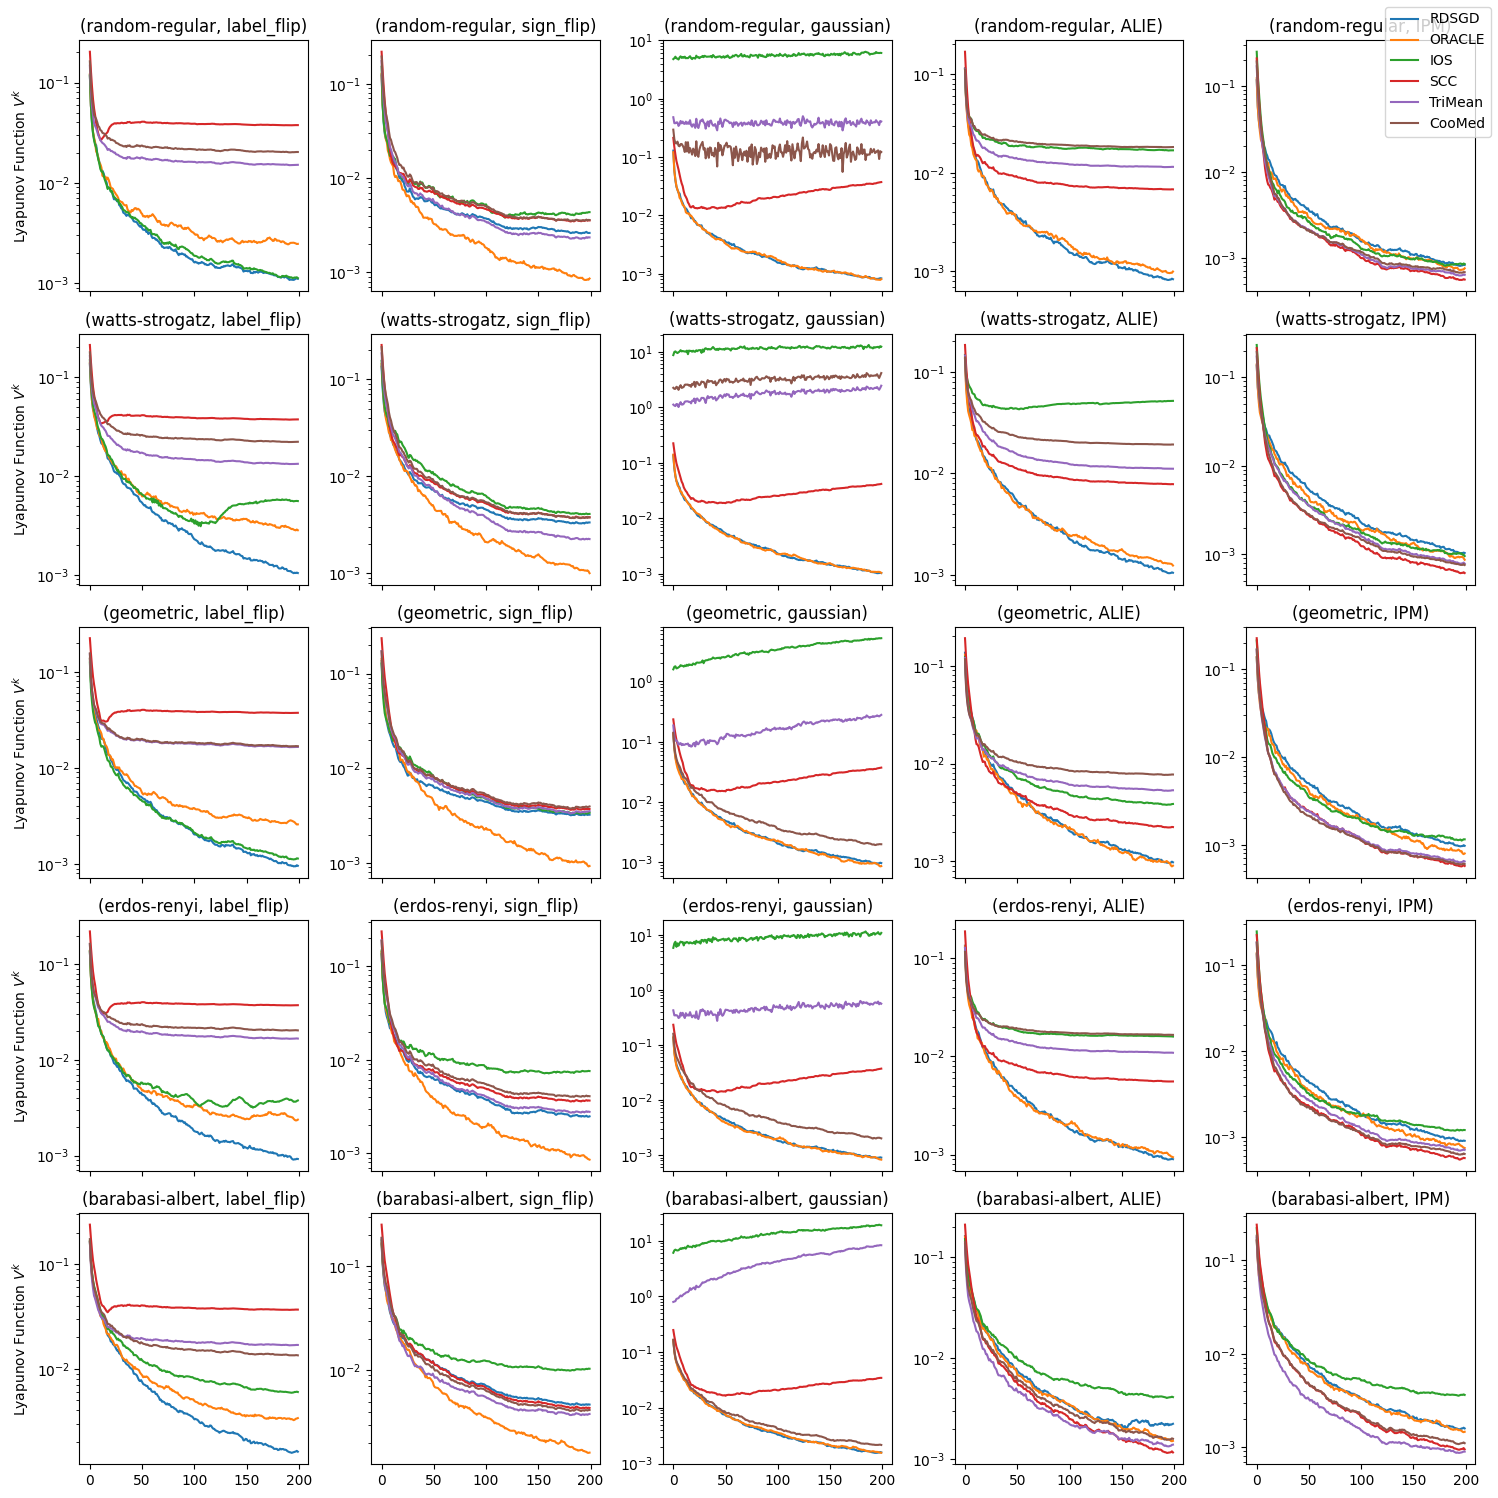

In [10]:
# Aggregate simulation results and save to disk
R = {(g, atk, s): (df, consts) for g, atk, s, df, consts in res2}
rows, met_rows, clf_rows = [], [], []
fig1, ax1 = plt.subplots(len(graphs), len(ATKS),
                         figsize=(3 * len(ATKS), 3 * len(graphs)),
                         squeeze=False, sharex=True)
ta_tables = dict()

for g_idx, g in enumerate(graphs):
    ax = ax1[g_idx]
    clf_rows.append({'graph': g, 'proj_const': P1[g]['proj_const'],
                     **P1[g]['op_pt'], **P1[g]['metrics']})
    for atk_idx, atk in enumerate(ATKS):
        for s in SEEDS:
            df, consts = R[(g, atk, s)]
            first = (s == SEEDS[0])
            if first:
                df.to_csv(os.path.join(RUN_DIR, g, f'sys_sim_df_{g}_{b}_{atk}.csv'))
                met_rows.append({**consts, 'atk': atk, 'graph': g})
            for alg in ALGS:
                col = 'test_acc_pi' if alg == 'RDSGD' else 'test_acc'
                rows.append({'alg': alg, 'atk': atk, 'seed': s,
                             'graph': g, 'test_acc': df.loc[alg, col].iloc[-1]})
                if first:
                    V = df.loc[alg, 'C_unif'] + np.pow(df.loc[alg, 'opt_gap'], 2)
                    if(atk_idx == 0): 
                        if(g_idx == len(graphs)-1):
                            ax[atk_idx].plot(V, color=COLORS[alg], label=alg)
                            ax[atk_idx].set_xlabel='Iteration (k)'
                        else:
                            ax[atk_idx].plot(V, color=COLORS[alg])
                        ax[atk_idx].set_ylabel("Lyapunov Function $V^{k}$")
                    else: 
                        ax[atk_idx].plot(V, color=COLORS[alg])
                        ax[atk_idx].set_ylabel("")
                    ax[atk_idx].set(title=f'({g}, {atk})', yscale='log')


pd.DataFrame(clf_rows).set_index('graph').to_csv(os.path.join(RUN_DIR, f'clf_metrics_{b}.csv'))
pd.DataFrame(met_rows).set_index(['graph','atk']).to_csv(os.path.join(RUN_DIR, f'sys_metrics_{b}.csv'))

df_all = pd.DataFrame(rows)
df_summary = df_all.groupby(['graph','atk','alg'])['test_acc'].agg(['mean','std']).unstack('alg')
df_summary.to_csv(os.path.join(RUN_DIR, "test_accuracy.csv"))
                    
fig1.legend(loc="upper right")
fig1.tight_layout()
os.makedirs(IMAGES_DIR, exist_ok=True)
fig1.savefig(os.path.join(IMAGES_DIR, f'conv_plots_{g}_{b}.png'))

In [11]:
df_tmp = df_summary['mean'].drop(columns=['ORACLE'])
filt = df_tmp.max(axis=1) == df_tmp['RDSGD']
display(df_tmp[~filt])

alg                          CooMed       IOS     RDSGD       SCC   TriMean
graph           atk                                                        
barabasi-albert IPM        0.851939  0.850009  0.851567  0.851931  0.851481
erdos-renyi     IPM        0.852052  0.850303  0.851792  0.852364  0.852113
geometric       IPM        0.852017  0.850563  0.851818  0.851931  0.852035
random-regular  IPM        0.851567  0.850165  0.851758  0.852234  0.851758
                sign_flip  0.844857  0.844407  0.847299  0.845108  0.847558
watts-strogatz  IPM        0.851810  0.851342  0.851810  0.852242  0.852000
                sign_flip  0.844978  0.847229  0.845524  0.844814  0.848182

In [37]:
df2 = df_tmp[~filt]
df_cmp = (df2.T - df2.max(axis=1).to_numpy()).T
df_cmp.min(axis=1)

graph            atk      
barabasi-albert  IPM         -0.001931
erdos-renyi      IPM         -0.002061
geometric        IPM         -0.001472
random-regular   IPM         -0.002069
                 sign_flip   -0.003152
watts-strogatz   IPM         -0.000900
                 sign_flip   -0.003368
dtype: float64

In [38]:
df_cmp

alg                          CooMed       IOS     RDSGD       SCC   TriMean
graph           atk                                                        
barabasi-albert IPM        0.000000 -0.001931 -0.000372 -0.000009 -0.000459
erdos-renyi     IPM       -0.000312 -0.002061 -0.000571  0.000000 -0.000251
geometric       IPM       -0.000017 -0.001472 -0.000216 -0.000104  0.000000
random-regular  IPM       -0.000667 -0.002069 -0.000476  0.000000 -0.000476
                sign_flip -0.002701 -0.003152 -0.000260 -0.002450  0.000000
watts-strogatz  IPM       -0.000433 -0.000900 -0.000433  0.000000 -0.000242
                sign_flip -0.003203 -0.000952 -0.002658 -0.003368  0.000000